#🟡🔵CodeAlpha Machine Learning Internship - Task 4   (Disease Prediction from Medical Data)
------------
Objective:
    Predict the possibility of heart disease based on patient data such as
    age, blood pressure, cholesterol, blood sugar, symptoms, etc.
-----------
Dataset:
    UCI Heart Disease Dataset (Cleveland)
    https://archive.ics.uci.edu/dataset/45/heart+disease
----------

Models used:
    - Logistic Regression
    - Random Forest Classifier
    - Support Vector Machine (SVM)
---------
Evaluation:
    - Precision, Recall, F1-Score
    - ROC-AUC
    - Confusion Matrix
    - ROC Curve plot
    - Feature Importance

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_score, recall_score, f1_score,
)
import joblib

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 120


# ---------------------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------------------
def load_data():
    """
    Try to load the real UCI Heart Disease (Cleveland) dataset.
    If that fails (no internet), generate a realistic synthetic dataset
    with the same kind of features so the pipeline still runs end-to-end.
    """
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "heart-disease/processed.cleveland.data")
    columns = [
        "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
    ]
    try:
        df = pd.read_csv(url, header=None, names=columns, na_values="?")
        df = df.dropna().reset_index(drop=True)
        for col in ["ca", "thal"]:
            df[col] = df[col].astype(float)
        # Original target: 0 = no disease, 1-4 = increasing severity -> binary
        df["target"] = (df["target"] > 0).astype(int)
        print("Loaded REAL dataset: UCI Heart Disease (Cleveland)")
        return df, True
    except Exception as e:
        print(f"Could not download real dataset ({e}). Using synthetic data.")
        return generate_synthetic_data(), False


def generate_synthetic_data(n_samples=1000):
    """Generate a synthetic but realistic patient/medical dataset."""
    rng = np.random.default_rng(RANDOM_STATE)

    age = rng.integers(29, 77, n_samples)
    sex = rng.integers(0, 2, n_samples)  # 0 = female, 1 = male
    resting_bp = rng.normal(131, 17, n_samples).clip(90, 200)
    cholesterol = rng.normal(246, 51, n_samples).clip(120, 450)
    fasting_blood_sugar = rng.integers(0, 2, n_samples)  # >120 mg/dl = 1
    max_heart_rate = rng.normal(150, 22, n_samples).clip(70, 202)
    exercise_angina = rng.integers(0, 2, n_samples)
    oldpeak = rng.normal(1.0, 1.1, n_samples).clip(0, 6.2)
    num_major_vessels = rng.integers(0, 4, n_samples)

    risk_score = (
        (age / 100)
        + (resting_bp / 200) * 1.5
        + (cholesterol / 300) * 1.2
        + (fasting_blood_sugar * 0.4)
        - (max_heart_rate / 250)
        + (exercise_angina * 0.8)
        + (oldpeak * 0.5)
        + (num_major_vessels * 0.4)
        + rng.normal(0, 0.4, n_samples)
    )
    target = (risk_score > np.median(risk_score)).astype(int)

    return pd.DataFrame({
        "age": age, "sex": sex, "resting_bp": resting_bp,
        "cholesterol": cholesterol, "fasting_blood_sugar": fasting_blood_sugar,
        "max_heart_rate": max_heart_rate, "exercise_angina": exercise_angina,
        "oldpeak": oldpeak, "num_major_vessels": num_major_vessels,
        "target": target,
    })


# ---------------------------------------------------------------------
# 2. PREPROCESSING
# ---------------------------------------------------------------------
def preprocess(df):
    X = df.drop(columns=["target"])
    y = df["target"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, X.columns


# ---------------------------------------------------------------------
# 3. TRAIN MODELS
# ---------------------------------------------------------------------
def train_models(X_train, y_train):
    log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    log_reg.fit(X_train, y_train)

    rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)

    svm = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
    svm.fit(X_train, y_train)

    return {"Logistic Regression": log_reg, "Random Forest": rf, "SVM": svm}


# ---------------------------------------------------------------------
# VISUALIZATIONS
# ---------------------------------------------------------------------
def plot_class_balance(df):
    plt.figure(figsize=(5, 5))
    counts = df["target"].value_counts().sort_index()
    labels = ["No Disease", "Disease"]
    colors = ["#4CAF50", "#E53935"]
    plt.pie(counts, labels=labels, autopct="%1.1f%%", colors=colors,
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
    plt.title("Class Distribution: Disease vs No Disease", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.savefig("1_class_distribution.png", bbox_inches="tight")
    plt.close()


def plot_correlation_heatmap(df):
    plt.figure(figsize=(10, 8))
    corr = df.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Feature Correlation Heatmap", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.savefig("2_correlation_heatmap.png", bbox_inches="tight")
    plt.close()


def plot_feature_distributions(df, feature_names):
    key_features = list(feature_names)[:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(key_features):
        sns.histplot(data=df, x=col, hue="target", kde=True, ax=axes[i],
                     palette=["#4CAF50", "#E53935"], alpha=0.6, legend=(i == 0))
        axes[i].set_title(f"{col} distribution", fontsize=11, weight="bold")
    if len(key_features) < len(axes):
        for j in range(len(key_features), len(axes)):
            fig.delaxes(axes[j])
    plt.suptitle("Feature Distributions by Disease Status", fontsize=15, weight="bold")
    plt.tight_layout()
    plt.savefig("3_feature_distributions.png", bbox_inches="tight")
    plt.close()


def plot_confusion_matrices(models, X_test, y_test):
    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
    for ax, (name, model) in zip(axes, models.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["No Disease", "Disease"],
                    yticklabels=["No Disease", "Disease"], ax=ax,
                    annot_kws={"size": 14, "weight": "bold"})
        ax.set_title(f"{name}", fontsize=12, weight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.suptitle("Confusion Matrices", fontsize=15, weight="bold")
    plt.tight_layout()
    plt.savefig("4_confusion_matrices.png", bbox_inches="tight")
    plt.close()


def plot_roc_curves(models, X_test, y_test):
    plt.figure(figsize=(7, 6))
    colors = ["#1976D2", "#F57C00", "#7B1FA2"]
    for (name, model), color in zip(models.items(), colors):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})", color=color, linewidth=2.5)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
    plt.xlabel("False Positive Rate", fontsize=11)
    plt.ylabel("True Positive Rate", fontsize=11)
    plt.title("ROC Curve Comparison", fontsize=14, weight="bold")
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("5_roc_curve_comparison.png", bbox_inches="tight")
    plt.close()


def plot_feature_importance(rf_model, feature_names):
    importances = pd.Series(rf_model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True)
    plt.figure(figsize=(8, 6))
    importances.plot(kind="barh", color=sns.color_palette("viridis", len(importances)))
    plt.title("Feature Importance (Random Forest)", fontsize=14, weight="bold")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("6_feature_importance.png", bbox_inches="tight")
    plt.close()


def plot_metrics_comparison(models, X_test, y_test):
    records = []
    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        records.append({
            "Model": name,
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        })
    metrics_df = pd.DataFrame(records).set_index("Model")

    ax = metrics_df.plot(kind="bar", figsize=(10, 6), colormap="viridis",
                          edgecolor="black", width=0.75)
    plt.title("Model Performance Comparison", fontsize=14, weight="bold")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.legend(loc="lower right")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
    plt.tight_layout()
    plt.savefig("7_metrics_comparison.png", bbox_inches="tight")
    plt.close()
    return metrics_df


def evaluate_models(models, X_test, y_test):
    for name, model in models.items():
        y_pred = model.predict(X_test)
        print(f"\n===== {name} =====")
        print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))


# ---------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------
def main():
    df, is_real = load_data()
    print(f"\nDataset shape: {df.shape}")

    X_train, X_test, y_train, y_test, scaler, feature_names = preprocess(df)
    models = train_models(X_train, y_train)

    evaluate_models(models, X_test, y_test)

    # --- Generate all visualizations ---
    plot_class_balance(df)
    plot_correlation_heatmap(df)
    plot_feature_distributions(df, feature_names)
    plot_confusion_matrices(models, X_test, y_test)
    plot_roc_curves(models, X_test, y_test)
    plot_feature_importance(models["Random Forest"], feature_names)
    metrics_df = plot_metrics_comparison(models, X_test, y_test)

    print("\nFinal Metrics Table:\n", metrics_df.round(3))
    print("\nSaved visualizations:")
    print("  1_class_distribution.png\n  2_correlation_heatmap.png")
    print("  3_feature_distributions.png\n  4_confusion_matrices.png")
    print("  5_roc_curve_comparison.png\n  6_feature_importance.png")
    print("  7_metrics_comparison.png")

    joblib.dump(models["Random Forest"], "disease_prediction_model.pkl")
    joblib.dump(scaler, "disease_prediction_scaler.pkl")
    print("\nModel and scaler saved as .pkl files.")


if __name__ == "__main__":
    main()

Loaded REAL dataset: UCI Heart Disease (Cleveland)

Dataset shape: (297, 14)

===== Logistic Regression =====
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60


===== Random Forest =====
              precision    recall  f1-score   support

  No Disease       0.78      0.88      0.82        32
     Disease       0.83      0.71      0.77        28

    accuracy                           0.80        60
   macro avg       0.81      0.79      0.80        60
weighted avg       0.80      0.80      0.80        60


===== SVM =====
              precision    recall  f1-score   support

  No Disease       0.83      0.91      0.87        32
     Disease       0.88      0.79      0.83        28

    accuracy                

### 📊 Class Distribution: Disease vs No Disease

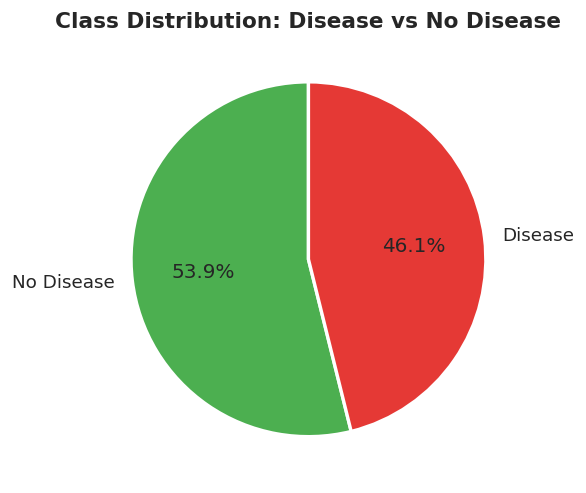

### 🔥 Feature Correlation Heatmap

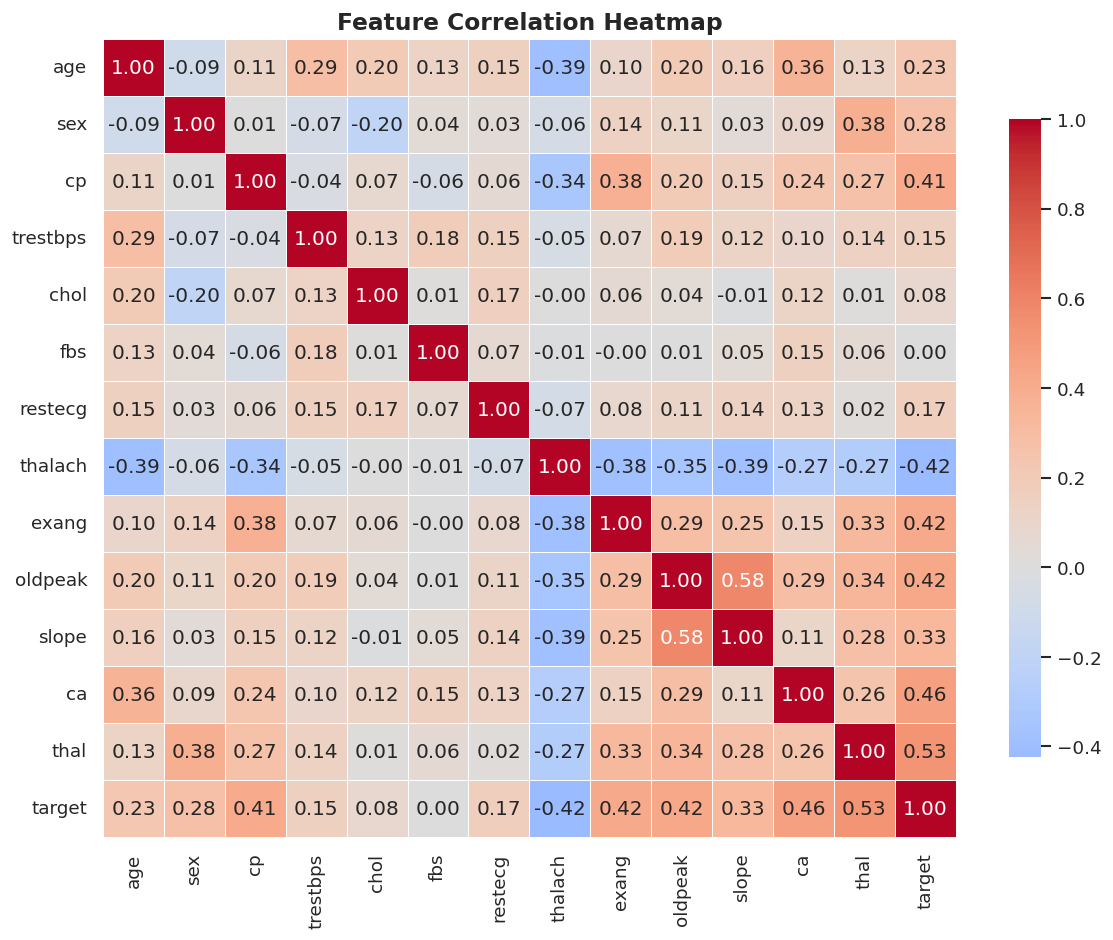

### 📈 Feature Distributions by Disease Status

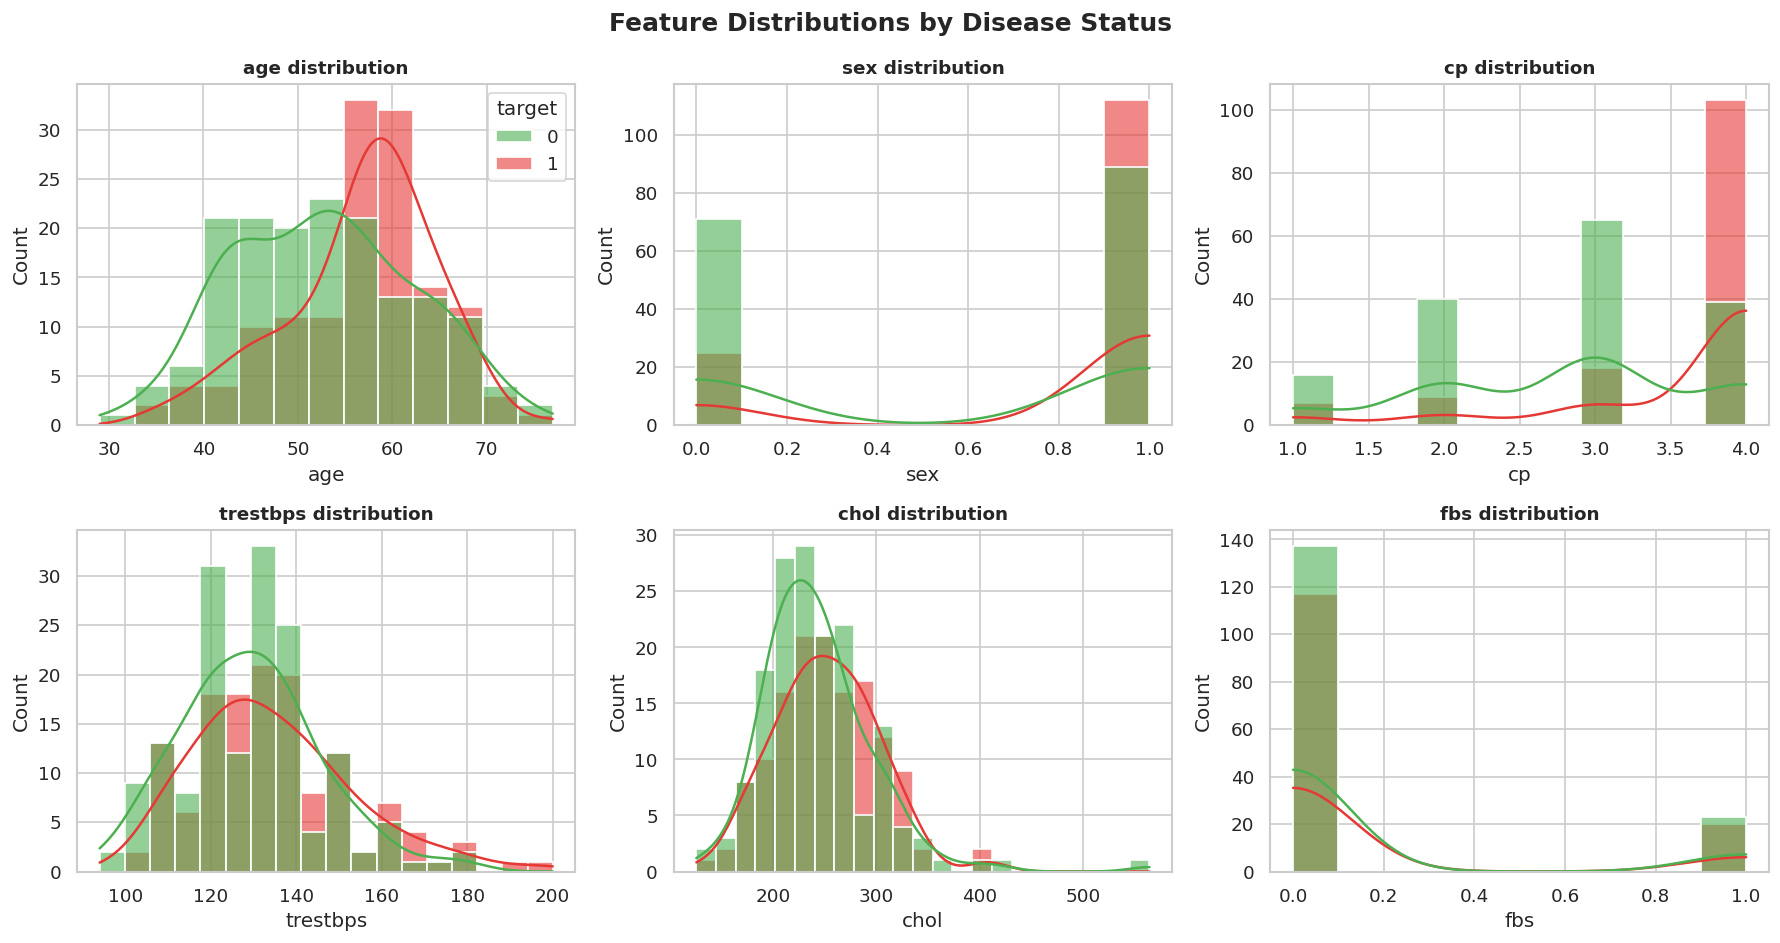

### 🧩 Confusion Matrices

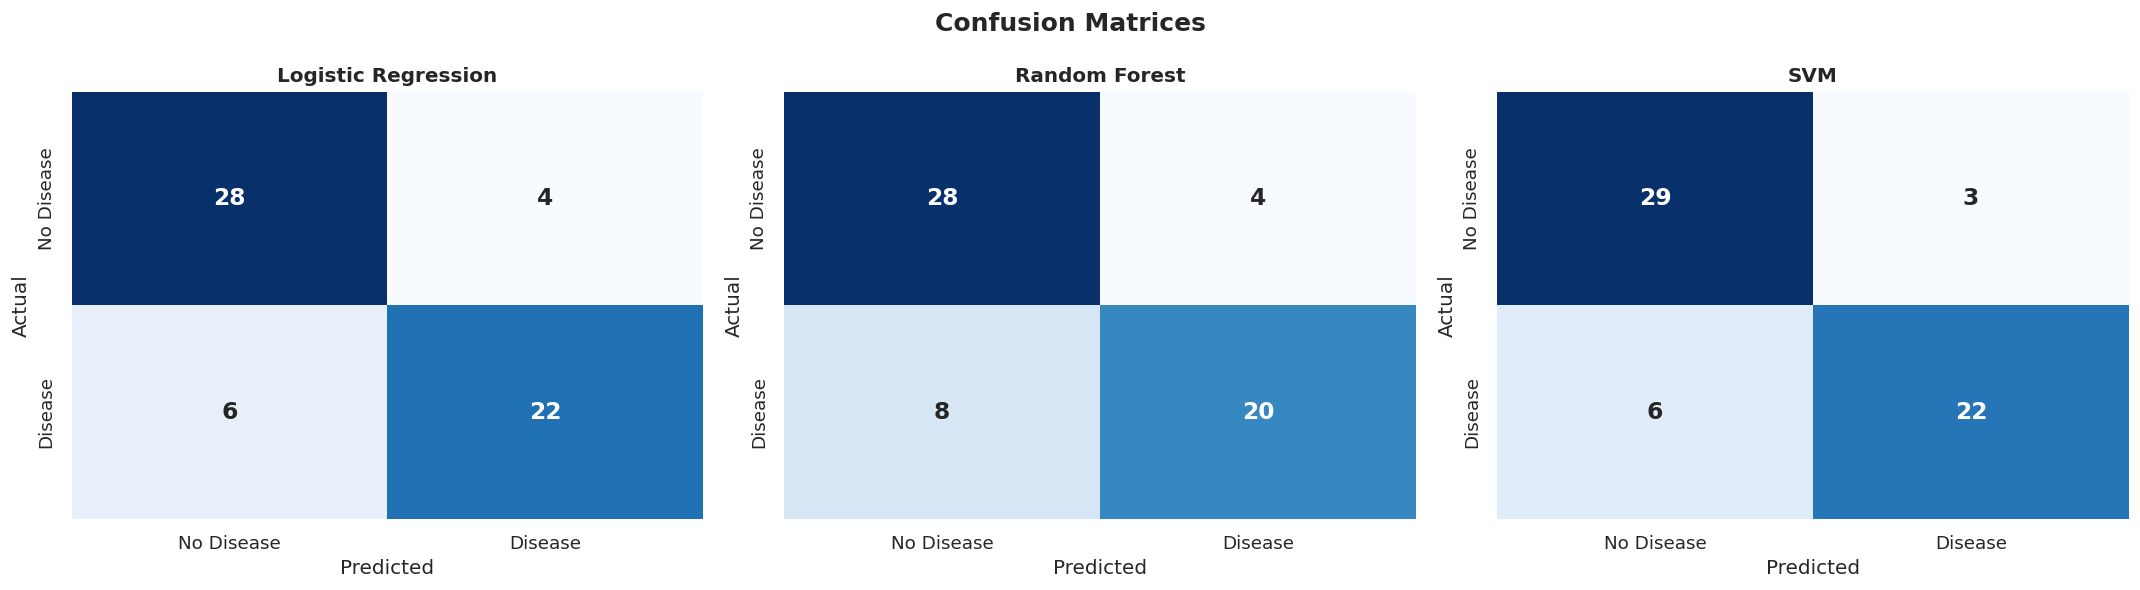

### 📉 ROC Curve Comparison

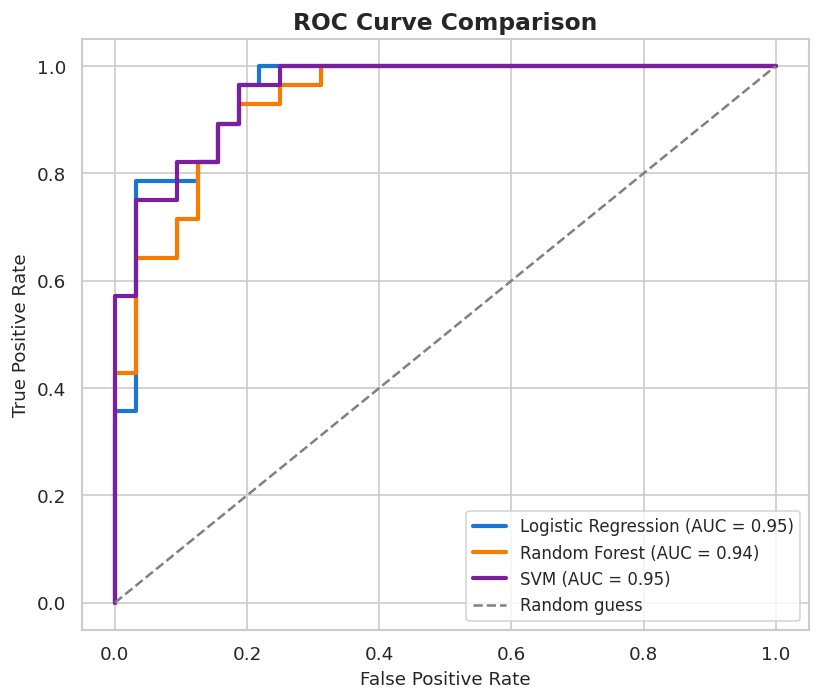

### 🌟 Feature Importance (Random Forest)

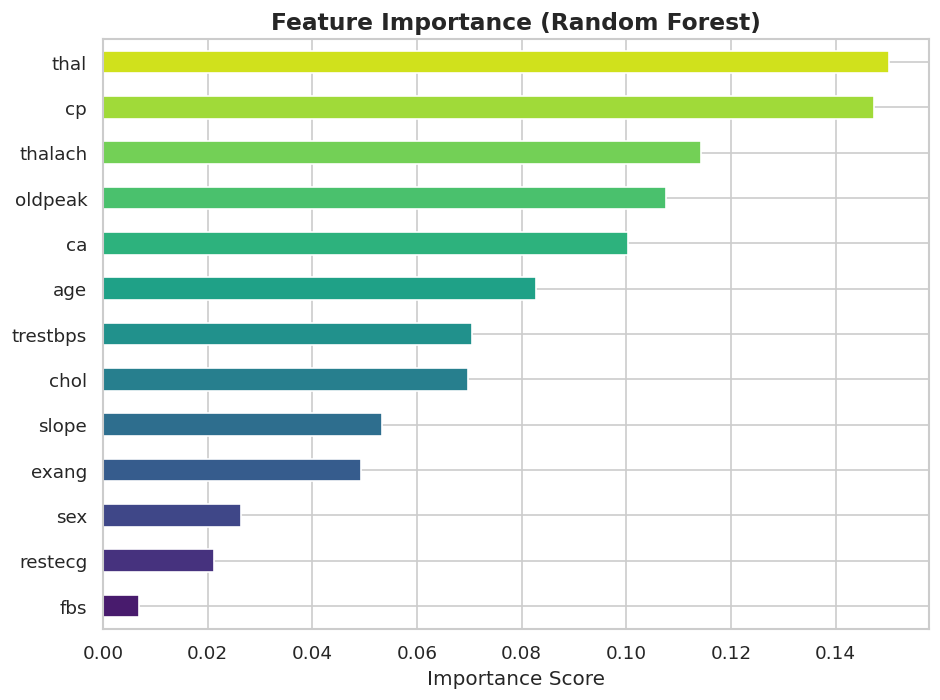

### 🏆 Model Performance Comparison

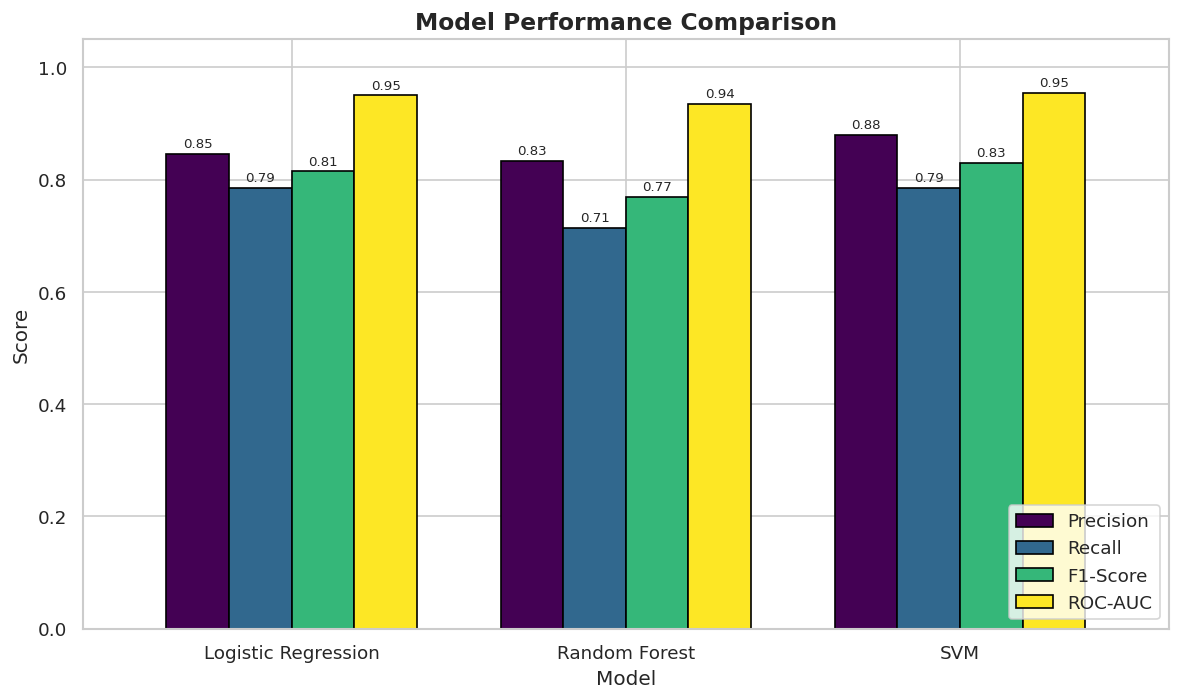

In [2]:
from IPython.display import Image, display, Markdown

visualizations = [
    ("1_class_distribution.png", "📊 Class Distribution: Disease vs No Disease"),
    ("2_correlation_heatmap.png", "🔥 Feature Correlation Heatmap"),
    ("3_feature_distributions.png", "📈 Feature Distributions by Disease Status"),
    ("4_confusion_matrices.png", "🧩 Confusion Matrices"),
    ("5_roc_curve_comparison.png", "📉 ROC Curve Comparison"),
    ("6_feature_importance.png", "🌟 Feature Importance (Random Forest)"),
    ("7_metrics_comparison.png", "🏆 Model Performance Comparison"),
]

for filename, title in visualizations:
    display(Markdown(f"### {title}"))
    display(Image(filename=filename))